**01_decoder_architecture.ipynb**

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


**Cell 2 — Causal Mask**

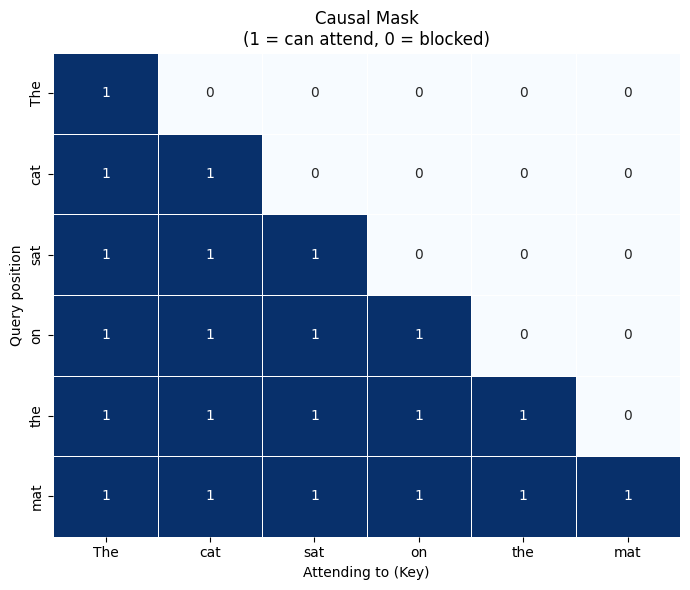

Causal mask:
tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])

Row 0 ('The'): can only attend to itself
Row 2 ('sat'): can attend to 'The', 'cat', 'sat'
Row 5 ('mat'): can attend to all previous tokens


In [2]:
# The core of decoder-only models — the causal mask
# Prevents attending to future positions

def create_causal_mask(seq_len):
    """
    Creates a triangular mask that prevents attending to future tokens.
    
    Returns a (seq_len, seq_len) matrix where:
      1 = allowed to attend
      0 = blocked (future position)
    """
    mask = torch.tril(torch.ones(seq_len, seq_len))
    return mask

# Visualise
seq_len = 6
mask = create_causal_mask(seq_len)

tokens = ["The", "cat", "sat", "on", "the", "mat"]

plt.figure(figsize=(7, 6))
sns.heatmap(mask.numpy(), annot=True, fmt='.0f', cmap='Blues',
            xticklabels=tokens, yticklabels=tokens,
            cbar=False, linewidths=0.5)
plt.title("Causal Mask\n(1 = can attend, 0 = blocked)")
plt.xlabel("Attending to (Key)")
plt.ylabel("Query position")
plt.tight_layout()
plt.show()

print("Causal mask:")
print(mask)
print("\nRow 0 ('The'): can only attend to itself")
print("Row 2 ('sat'): can attend to 'The', 'cat', 'sat'")
print("Row 5 ('mat'): can attend to all previous tokens")

**Cell 3 — Causal Attention**

In [3]:
class CausalSelfAttention(nn.Module):
    """
    Self-attention with causal masking.
    Each token can only attend to previous tokens (and itself).
    """
    
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        
        assert d_model % num_heads == 0
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        # Q, K, V projections (combined for efficiency)
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, d_model)
        Returns:
            output: (batch, seq_len, d_model)
            attn_weights: (batch, num_heads, seq_len, seq_len)
        """
        batch, seq_len, d_model = x.shape
        
        # Compute Q, K, V together
        qkv = self.qkv(x)
        q, k, v = qkv.split(d_model, dim=2)
        
        # Reshape for multi-head attention
        q = q.view(batch, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        k = k.view(batch, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        v = v.view(batch, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        # Shape: (batch, num_heads, seq_len, d_k)
        
        # Scaled dot-product attention
        scores = torch.matmul(q, k.transpose(-2, -1)) / np.sqrt(self.d_k)
        # scores: (batch, num_heads, seq_len, seq_len)
        
        # Apply causal mask
        causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device))
        scores = scores.masked_fill(causal_mask == 0, float('-inf'))
        # -inf → softmax → 0 (effectively blocks those positions)
        
        # Softmax
        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Apply to values
        out = torch.matmul(attn_weights, v)
        # out: (batch, num_heads, seq_len, d_k)
        
        # Reshape back
        out = out.transpose(1, 2).contiguous().view(batch, seq_len, d_model)
        out = self.out_proj(out)
        
        return out, attn_weights

# Test
batch, seq_len, d_model = 2, 6, 64
x = torch.randn(batch, seq_len, d_model)
attn = CausalSelfAttention(d_model=64, num_heads=4)
out, weights = attn(x)

print(f"Input:  {x.shape}")
print(f"Output: {out.shape}")
print(f"Attention weights: {weights.shape}")
print(f"\nAttention weights for head 0, batch 0:")
print(weights[0, 0].detach().numpy().round(3))
print("\nObserve: upper triangle is 0 (causal mask working!)")

Input:  torch.Size([2, 6, 64])
Output: torch.Size([2, 6, 64])
Attention weights: torch.Size([2, 4, 6, 6])

Attention weights for head 0, batch 0:
[[1.111 0.    0.    0.    0.    0.   ]
 [0.568 0.543 0.    0.    0.    0.   ]
 [0.421 0.337 0.354 0.    0.    0.   ]
 [0.227 0.345 0.229 0.31  0.    0.   ]
 [0.273 0.17  0.178 0.346 0.144 0.   ]
 [0.282 0.163 0.    0.173 0.    0.165]]

Observe: upper triangle is 0 (causal mask working!)


**Cell 4 — Visualise Causal Attention Weights**

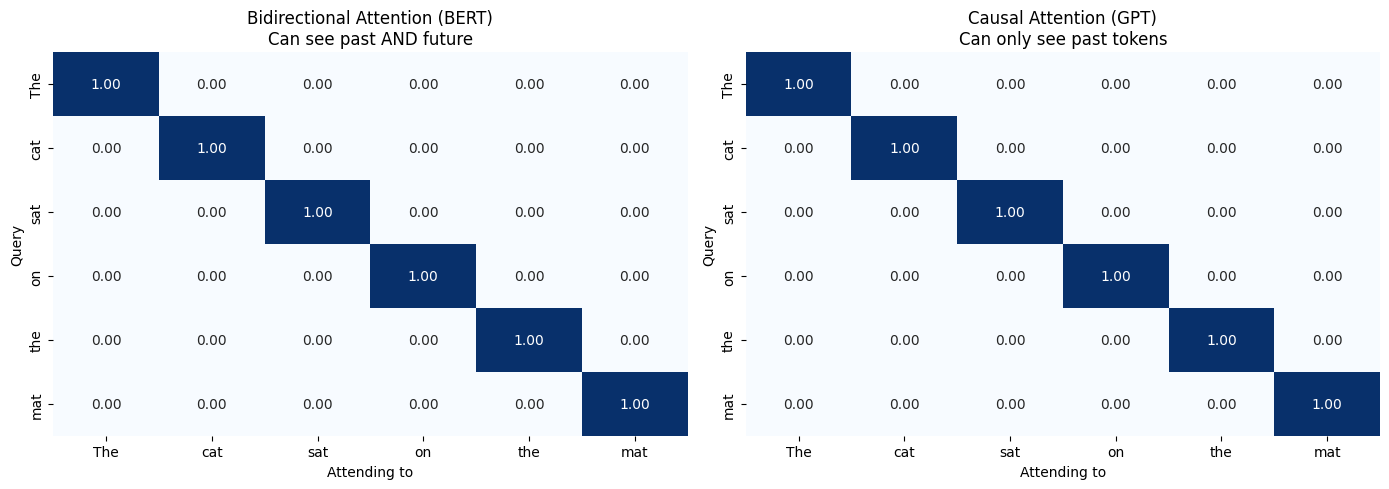

Key observation:
  BERT: every token attends to all tokens
  GPT:  each token only attends to previous tokens
  Upper triangle in GPT is 0 (future is blocked)


In [4]:
# Show how causal masking affects attention patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tokens = ["The", "cat", "sat", "on", "the", "mat"]

# Regular (BERT-style) attention — no mask
x = torch.randn(1, 6, 64)
regular_scores = torch.matmul(x, x.transpose(-2, -1)) / np.sqrt(64)
regular_weights = torch.softmax(regular_scores, dim=-1)

ax = axes[0]
sns.heatmap(regular_weights[0].detach().numpy(), annot=True, fmt='.2f',
            cmap='Blues', ax=ax,
            xticklabels=tokens, yticklabels=tokens, cbar=False)
ax.set_title("Bidirectional Attention (BERT)\nCan see past AND future")
ax.set_xlabel("Attending to")
ax.set_ylabel("Query")

# Causal (GPT-style) attention — with mask
causal_scores = regular_scores.clone()
mask = torch.tril(torch.ones(6, 6))
causal_scores = causal_scores.masked_fill(mask == 0, float('-inf'))
causal_weights = torch.softmax(causal_scores, dim=-1)

ax = axes[1]
sns.heatmap(causal_weights[0].detach().numpy(), annot=True, fmt='.2f',
            cmap='Blues', ax=ax,
            xticklabels=tokens, yticklabels=tokens, cbar=False)
ax.set_title("Causal Attention (GPT)\nCan only see past tokens")
ax.set_xlabel("Attending to")
ax.set_ylabel("Query")

plt.tight_layout()
plt.show()

print("Key observation:")
print("  BERT: every token attends to all tokens")
print("  GPT:  each token only attends to previous tokens")
print("  Upper triangle in GPT is 0 (future is blocked)")

**Cell 5 — Full Decoder Block**

In [5]:
class DecoderBlock(nn.Module):
    """
    Single GPT-style decoder block:
    - Causal self-attention
    - Residual + LayerNorm
    - Feed-forward
    - Residual + LayerNorm
    """
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        
        self.attn = CausalSelfAttention(d_model, num_heads, dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),          # GPT uses GELU (not ReLU)
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # Attention + residual
        attn_out, attn_weights = self.attn(self.norm1(x))
        x = x + self.dropout(attn_out)
        
        # FFN + residual
        x = x + self.dropout(self.ffn(self.norm2(x)))
        
        return x, attn_weights

# Test
block = DecoderBlock(d_model=64, num_heads=4, d_ff=256)
x = torch.randn(2, 6, 64)
out, weights = block(x)

print(f"Input:  {x.shape}")
print(f"Output: {out.shape}")
print(f"Parameters: {sum(p.numel() for p in block.parameters()):,}")
print("\nNote: GELU (not ReLU) — GPT-style activation")

Input:  torch.Size([2, 6, 64])
Output: torch.Size([2, 6, 64])
Parameters: 49,984

Note: GELU (not ReLU) — GPT-style activation


**Cell 6 — Mini GPT (Full Decoder-Only Model)**

In [6]:
class MiniGPT(nn.Module):
    """
    Minimal GPT-style decoder-only language model.
    Stack of decoder blocks with token + position embeddings.
    """
    
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, 
                 max_seq_len=512, dropout=0.1):
        super().__init__()
        
        self.d_model = d_model
        
        # Token embedding
        self.token_emb = nn.Embedding(vocab_size, d_model)
        
        # Positional embedding (learned, not sinusoidal like BERT)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        
        # Decoder blocks
        self.blocks = nn.ModuleList([
            DecoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # Final layer norm
        self.norm = nn.LayerNorm(d_model)
        
        # Output projection (d_model → vocab_size)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, token_ids):
        """
        Args:
            token_ids: (batch, seq_len)
        Returns:
            logits: (batch, seq_len, vocab_size)
        """
        batch, seq_len = token_ids.shape
        
        # Token embeddings
        tok_emb = self.token_emb(token_ids)
        
        # Positional embeddings
        positions = torch.arange(seq_len, device=token_ids.device)
        pos_emb = self.pos_emb(positions)
        
        # Combine
        x = self.dropout(tok_emb + pos_emb)
        
        # Pass through all decoder blocks
        all_attn_weights = []
        for block in self.blocks:
            x, attn_weights = block(x)
            all_attn_weights.append(attn_weights)
        
        # Final norm
        x = self.norm(x)
        
        # Project to vocabulary
        logits = self.head(x)
        
        return logits, all_attn_weights

# Create a small model
vocab_size = 1000
model = MiniGPT(
    vocab_size=vocab_size,
    d_model=64,
    num_heads=4,
    d_ff=256,
    num_layers=2,
    max_seq_len=128,
    dropout=0.1
).to(device)

# Test forward pass
token_ids = torch.randint(0, vocab_size, (2, 10)).to(device)
logits, all_weights = model(token_ids)

print(f"Input token IDs: {token_ids.shape}")
print(f"Output logits:   {logits.shape}")
print(f"  (batch=2, seq_len=10, vocab_size={vocab_size})")
print(f"\nNumber of decoder layers: {len(all_weights)}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nCompare to GPT-2: 124M parameters")
print(f"Our mini model: {sum(p.numel() for p in model.parameters()):,} parameters")

Input token IDs: torch.Size([2, 10])
Output logits:   torch.Size([2, 10, 1000])
  (batch=2, seq_len=10, vocab_size=1000)

Number of decoder layers: 2
Total parameters: 236,288

Compare to GPT-2: 124M parameters
Our mini model: 236,288 parameters


**Cell 7 — Autoregressive Generation**

In [7]:
def generate(model, token_ids, max_new_tokens=10, temperature=1.0, top_k=10):
    """
    Autoregressive text generation.
    
    Each step:
    1. Forward pass through model
    2. Take logits at last position
    3. Apply temperature and top-k
    4. Sample next token
    5. Append to sequence and repeat
    """
    model.eval()
    generated = token_ids.clone()
    
    with torch.no_grad():
        for step in range(max_new_tokens):
            # Forward pass
            logits, _ = model(generated)
            
            # Take logits at last position only
            next_logits = logits[:, -1, :]  # (batch, vocab_size)
            
            # Apply temperature (scale logits)
            next_logits = next_logits / temperature
            
            # Apply top-k (zero out all but top k logits)
            if top_k > 0:
                values, _ = torch.topk(next_logits, top_k)
                min_val = values[:, -1].unsqueeze(-1)
                next_logits = next_logits.masked_fill(next_logits < min_val, float('-inf'))
            
            # Convert to probabilities
            probs = torch.softmax(next_logits, dim=-1)
            
            # Sample next token
            next_token = torch.multinomial(probs, num_samples=1)  # (batch, 1)
            
            # Append to sequence
            generated = torch.cat([generated, next_token], dim=1)
    
    return generated

# Test generation
print("="*70)
print("AUTOREGRESSIVE GENERATION")
print("="*70)

# Start with a prompt (random token IDs for now)
prompt = torch.randint(0, vocab_size, (1, 5)).to(device)
print(f"\nPrompt token IDs: {prompt[0].tolist()}")

# Generate with different temperatures
for temp in [0.5, 1.0, 2.0]:
    generated = generate(model, prompt, max_new_tokens=10, temperature=temp)
    new_tokens = generated[0, 5:].tolist()  # Only show new tokens
    print(f"\nTemperature {temp}: {new_tokens}")

print(f"\nLow temp (0.5):  More focused, less diverse")
print(f"Medium temp (1.0): Balanced")
print(f"High temp (2.0): More random, more diverse")

AUTOREGRESSIVE GENERATION

Prompt token IDs: [275, 728, 378, 359, 699]

Temperature 0.5: [839, 752, 695, 488, 171, 106, 867, 484, 568, 822]

Temperature 1.0: [163, 836, 702, 625, 402, 226, 376, 373, 662, 297]

Temperature 2.0: [235, 473, 434, 900, 722, 441, 509, 98, 827, 495]

Low temp (0.5):  More focused, less diverse
Medium temp (1.0): Balanced
High temp (2.0): More random, more diverse


**Cell 8 — Compare Encoder vs Decoder Attention**

ENCODER vs DECODER — ATTENTION COMPARISON


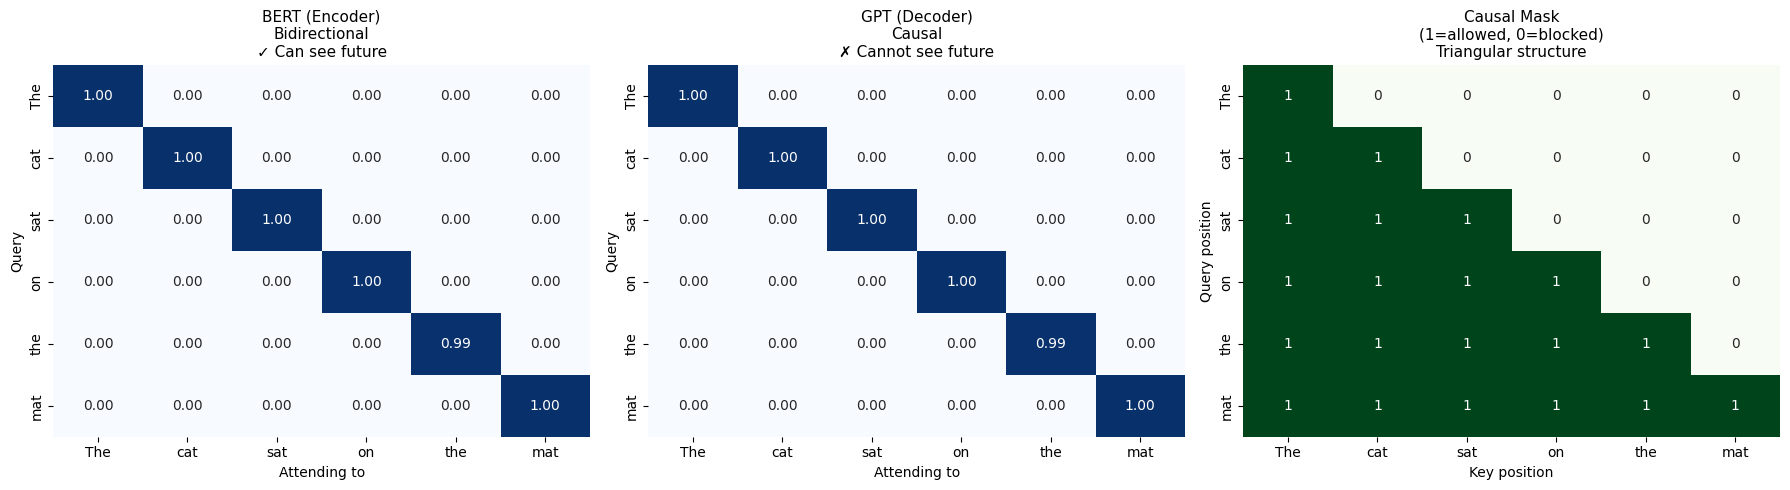


Key differences:
  BERT: All positions see all positions (bidirectional)
  GPT:  Position i sees only positions 0...i (causal)
  Mask: Lower triangular matrix enforces causality


In [8]:
# Side-by-side comparison of BERT vs GPT attention
print("="*70)
print("ENCODER vs DECODER — ATTENTION COMPARISON")
print("="*70)

seq_len = 6
tokens = ["The", "cat", "sat", "on", "the", "mat"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# BERT: Bidirectional (no mask)
x = torch.randn(1, seq_len, 64)
scores = torch.matmul(x, x.transpose(-2, -1)) / np.sqrt(64)
bert_weights = torch.softmax(scores, dim=-1)

ax = axes[0]
sns.heatmap(bert_weights[0].detach().numpy(), annot=True, fmt='.2f',
            cmap='Blues', ax=ax,
            xticklabels=tokens, yticklabels=tokens, cbar=False)
ax.set_title("BERT (Encoder)\nBidirectional\n✓ Can see future", fontsize=11)
ax.set_xlabel("Attending to")
ax.set_ylabel("Query")

# GPT: Causal (lower triangular mask)
causal_scores = scores.clone()
mask = torch.tril(torch.ones(seq_len, seq_len))
causal_scores = causal_scores.masked_fill(mask == 0, float('-inf'))
gpt_weights = torch.softmax(causal_scores, dim=-1)

ax = axes[1]
sns.heatmap(gpt_weights[0].detach().numpy(), annot=True, fmt='.2f',
            cmap='Blues', ax=ax,
            xticklabels=tokens, yticklabels=tokens, cbar=False)
ax.set_title("GPT (Decoder)\nCausal\n✗ Cannot see future", fontsize=11)
ax.set_xlabel("Attending to")
ax.set_ylabel("Query")

# Causal mask itself
ax = axes[2]
sns.heatmap(mask.numpy(), annot=True, fmt='.0f',
            cmap='Greens', ax=ax,
            xticklabels=tokens, yticklabels=tokens, cbar=False)
ax.set_title("Causal Mask\n(1=allowed, 0=blocked)\nTriangular structure", fontsize=11)
ax.set_xlabel("Key position")
ax.set_ylabel("Query position")

plt.tight_layout()
plt.show()

print("\nKey differences:")
print("  BERT: All positions see all positions (bidirectional)")
print("  GPT:  Position i sees only positions 0...i (causal)")
print("  Mask: Lower triangular matrix enforces causality")

**Cell 9 — Language Model Training Step**

In [9]:
# Show how training works for a decoder-only model
print("="*70)
print("LANGUAGE MODEL TRAINING OBJECTIVE")
print("="*70)

# Create a simple vocabulary
vocab = {
    'the': 0, 'cat': 1, 'sat': 2, 'on': 3, 'mat': 4,
    'dog': 5, 'ran': 6, 'in': 7, 'park': 8, '<pad>': 9
}
id_to_token = {v: k for k, v in vocab.items()}

# Example sentence: "the cat sat on the mat"
sentence = [vocab['the'], vocab['cat'], vocab['sat'], 
            vocab['on'], vocab['the'], vocab['mat']]

print(f"\nSentence: {[id_to_token[i] for i in sentence]}")
print(f"Token IDs: {sentence}")

# Input is all tokens except last
# Target is all tokens except first (shifted by 1)
input_ids = torch.tensor([sentence[:-1]])   # "the cat sat on the"
target_ids = torch.tensor([sentence[1:]])   # "cat sat on the mat"

print(f"\nInput:  {[id_to_token[i.item()] for i in input_ids[0]]}")
print(f"Target: {[id_to_token[i.item()] for i in target_ids[0]]}")
print(f"\nFor each position, model predicts the NEXT token:")
for i in range(len(sentence) - 1):
    print(f"  '{id_to_token[sentence[i]]}' → predict '{id_to_token[sentence[i+1]]}'")

# Create a tiny model for this vocabulary
tiny_model = MiniGPT(
    vocab_size=len(vocab),
    d_model=32,
    num_heads=2,
    d_ff=64,
    num_layers=1,
    max_seq_len=20,
    dropout=0.0
)

# Forward pass
logits, _ = tiny_model(input_ids)
print(f"\nLogits shape: {logits.shape}")
print(f"  (batch=1, seq_len={len(sentence)-1}, vocab_size={len(vocab)})")

# Compute loss
loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(logits.view(-1, len(vocab)), target_ids.view(-1))
print(f"\nInitial loss: {loss.item():.3f}")
print(f"(Untrained model, so loss is high)")
print(f"\nWith enough training steps on enough data:")
print(f"  Loss decreases → model learns to predict next token")
print(f"  This is EXACTLY how GPT-2, LLaMA, Claude are trained!")

LANGUAGE MODEL TRAINING OBJECTIVE

Sentence: ['the', 'cat', 'sat', 'on', 'the', 'mat']
Token IDs: [0, 1, 2, 3, 0, 4]

Input:  ['the', 'cat', 'sat', 'on', 'the']
Target: ['cat', 'sat', 'on', 'the', 'mat']

For each position, model predicts the NEXT token:
  'the' → predict 'cat'
  'cat' → predict 'sat'
  'sat' → predict 'on'
  'on' → predict 'the'
  'the' → predict 'mat'

Logits shape: torch.Size([1, 5, 10])
  (batch=1, seq_len=5, vocab_size=10)

Initial loss: 2.323
(Untrained model, so loss is high)

With enough training steps on enough data:
  Loss decreases → model learns to predict next token
  This is EXACTLY how GPT-2, LLaMA, Claude are trained!


**Cell 10 — Summary**

In [10]:
print("""
DECODER-ONLY ARCHITECTURE — SUMMARY

Key Components:
  1. Causal masking
     - Lower triangular matrix
     - Prevents attending to future tokens
     - Enforces "only know the past" constraint

  2. Autoregressive generation
     - Generate one token at a time
     - Feed output back as input
     - Stop at <END> token or max length

  3. Training objective
     - Predict next token at every position
     - One sentence → N training signals
     - Scale to trillions of tokens

  4. Decoder block (vs BERT encoder block)
     - Identical structure
     - ONLY difference: causal mask in attention
     - GELU instead of ReLU (GPT improvement)

  5. Sampling strategies
     - Greedy: pick highest probability
     - Temperature: scale diversity
     - Top-k: sample from top k tokens
     - Top-p (nucleus): sample from cumulative probability

BERT vs GPT:
  BERT → Encoder → Bidirectional → Classification
  GPT  → Decoder → Causal → Generation

All modern LLMs (GPT, LLaMA, Claude):
  → Decoder-only
  → Autoregressive
  → Trained on next-token prediction
  → Scaled to billions of parameters

Next: Read Karpathy's nanoGPT walkthrough
      Then: LoRA and efficient fine-tuning
""")


DECODER-ONLY ARCHITECTURE — SUMMARY

Key Components:
  1. Causal masking
     - Lower triangular matrix
     - Prevents attending to future tokens
     - Enforces "only know the past" constraint

  2. Autoregressive generation
     - Generate one token at a time
     - Feed output back as input
     - Stop at <END> token or max length

  3. Training objective
     - Predict next token at every position
     - One sentence → N training signals
     - Scale to trillions of tokens

  4. Decoder block (vs BERT encoder block)
     - Identical structure
     - ONLY difference: causal mask in attention
     - GELU instead of ReLU (GPT improvement)

  5. Sampling strategies
     - Greedy: pick highest probability
     - Temperature: scale diversity
     - Top-k: sample from top k tokens
     - Top-p (nucleus): sample from cumulative probability

BERT vs GPT:
  BERT → Encoder → Bidirectional → Classification
  GPT  → Decoder → Causal → Generation

All modern LLMs (GPT, LLaMA, Claude):
  → Deco